# Dialogue Act Features — Keyword Baseline

**Theory-driven approach:** directly operationalises the codebook cue words.

Each utterance is scored by counting how many cues for each DA type it contains.
Per-window features are the mean score per DA type (normalised by window utterance count).

**Advantage over zero-shot NLI:** fully transparent, no model needed, directly grounded in your codebook.  
**Limitation:** misses implicit acts that have no surface cue word.

Use both this and the NLI version — if they agree, the cues are good proxies.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

REPO_ROOT      = Path.cwd().parent if Path.cwd().name == 'analysis' else Path.cwd()
TRANSCRIPT_DIR = REPO_ROOT / 'transcripts' / 'final'
OUT_PATH       = REPO_ROOT / 'analysis' / 'results' / 'da_keyword_window_30s.tsv'

WINDOW_S     = 30.0
PARTICIPANTS = ('P1', 'P2', 'P3', 'P4')

print(f'Repo root: {REPO_ROOT}')

Repo root: c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing


## 1. Codebook Cue Words

In [2]:
# Cues taken directly from the codebook — multi-word phrases matched as substrings
DA_CUES = {
    'statement':    ['i think', 'in my view', 'it seems', 'for me', 'personally',
                     'i believe', 'from my point of view', 'i feel', 'in my opinion'],
    'proposal':     ['we could', 'how about', 'what if', "let's try", 'i suggest',
                     'maybe we should', 'one option is', "why don't we", 'we should',
                     'i propose', 'what about doing', 'could we'],
    'agreement':    ['exactly', 'i agree', "that's right", 'sounds good', 'absolutely',
                     'definitely', 'totally', 'i think so too', 'you\'re right',
                     'good point', 'that makes sense', 'i support'],
    'disagreement': ["i don't think so", 'not really', 'i disagree', "i'm not sure that",
                     'but actually', 'however', 'on the other hand', 'i would say no',
                     'that\'s not', 'i don\'t agree'],
    'compromise':   ['we could combine', 'maybe both', "let's mix", 'meet in the middle',
                     'compromise', 'bit of both', 'split the difference',
                     'middle ground', 'blend', 'combine both'],
    'question':     ['what do you think', 'should we', 'do we agree', 'what about',
                     'how do we', 'do you think', 'would you', 'can we', 'shall we',
                     'don\'t you think', 'right?', 'agree?'],
    'backchannel':  ['mm-hmm', 'uh-huh', 'mhm', 'mmh', 'okay', 'right', 'yep', 'yeah',
                     'sure', 'of course', 'go on', 'i see'],
    'hedge':        ['maybe', 'i guess', 'sort of', 'probably', 'not sure', 'kind of',
                     'i think maybe', 'perhaps', 'possibly', 'might be', 'not certain',
                     'i\'m not sure', 'could be'],
    'decision':     ["let's vote", 'majority', 'that\'s final', 'shall we decide',
                     'are we agreed', 'we decided', 'final decision', 'we agree on',
                     'decided', 'go with', 'we\'ll go with', 'we choose'],
    'offtask':      ['haha', 'lol', 'just kidding', 'by the way', 'anyway',
                     'off topic', 'unrelated', 'funny'],
}

# question mark as an additional signal for the question category
DA_QUESTION_MARK = True

print(f'{len(DA_CUES)} DA categories, cue counts per category:')
for k, v in DA_CUES.items():
    print(f'  {k:15s}: {len(v)} cues')

10 DA categories, cue counts per category:
  statement      : 9 cues
  proposal       : 12 cues
  agreement      : 12 cues
  disagreement   : 10 cues
  compromise     : 10 cues
  question       : 12 cues
  backchannel    : 12 cues
  hedge          : 13 cues
  decision       : 12 cues
  offtask        : 8 cues


## 2. Load Transcripts

In [3]:
_FNAME_RE = re.compile(r'transcript_(grp[_-]?\d+)_(T\d+)_', re.IGNORECASE)

def _normalize_group_id(raw):
    digits = re.sub(r'^grp[_-]?', '', raw.lower())
    return f'grp-{int(digits):02d}'

all_events = []
for fpath in TRANSCRIPT_DIR.glob('*.tsv'):
    m = _FNAME_RE.search(fpath.name)
    if not m:
        continue
    df = pd.read_csv(fpath, sep='\t')
    df['group_id'] = _normalize_group_id(m.group(1))
    df['task_id']  = m.group(2).upper()
    all_events.append(df)

events_df = pd.concat(all_events, ignore_index=True)

spk_events = events_df[
    (events_df['type'] == 'SPK') &
    (events_df['speaker'].isin(PARTICIPANTS)) &
    (events_df['text'].notna()) &
    (events_df['text'].str.strip() != '')
].copy()
spk_events['window_index'] = (spk_events['onset'] / WINDOW_S).apply(
    lambda x: int(x) if pd.notna(x) and x >= 0 else -1
)
spk_events = spk_events[spk_events['window_index'] >= 0].reset_index(drop=True)

print(f'Utterances: {len(spk_events)}')
print(f'Groups: {spk_events["group_id"].nunique()},  Tasks: {spk_events["task_id"].unique().tolist()}')

Utterances: 3248
Groups: 10,  Tasks: ['T1', 'T2', 'T3', 'T4']


## 3. Score Each Utterance

In [4]:
DA_CATEGORIES = list(DA_CUES.keys())
DA_PROB_COLS  = [f'da_{k}' for k in DA_CATEGORIES]

def score_utterance(text: str) -> dict:
    """Return raw cue-match count for each DA category."""
    t = text.lower()
    scores = {}
    for da, cues in DA_CUES.items():
        scores[da] = sum(1 for cue in cues if cue in t)
    # question mark adds to 'question'
    if DA_QUESTION_MARK and '?' in text:
        scores['question'] += 1
    return scores

# Apply to all utterances
score_rows = [score_utterance(t) for t in spk_events['text']]
score_df   = pd.DataFrame(score_rows)

# Dominant DA = category with highest cue count (ties broken alphabetically)
# Utterances with all zeros get label 'statement' as default (most common unlabelled act)
score_df['da_dominant'] = score_df[DA_CATEGORIES].idxmax(axis=1)
all_zero = score_df[DA_CATEGORIES].sum(axis=1) == 0
score_df.loc[all_zero, 'da_dominant'] = 'statement'

# Normalize raw counts to 0-1 per utterance (proportion of cues matched)
max_cues = {da: len(cues) for da, cues in DA_CUES.items()}
for da in DA_CATEGORIES:
    score_df[f'da_{da}_norm'] = (score_df[da] / max_cues[da]).clip(0, 1)

norm_cols = [f'da_{da}_norm' for da in DA_CATEGORIES]
print(f'Scored {len(score_df)} utterances')
print(f'Utterances with no cue match: {all_zero.sum()} ({all_zero.mean():.0%})')
print('\nDominant DA distribution:')
print(score_df['da_dominant'].value_counts())

Scored 3248 utterances
Utterances with no cue match: 1392 (43%)

Dominant DA distribution:
da_dominant
statement       1735
backchannel      697
question         456
hedge            166
agreement        113
proposal          37
disagreement      18
decision          13
offtask            7
compromise         6
Name: count, dtype: int64


## 4. Aggregate per 30s Window

In [5]:
spk_with_scores = pd.concat(
    [spk_events[['group_id', 'task_id', 'window_index', 'speaker']].reset_index(drop=True),
     score_df[norm_cols + ['da_dominant']]],
    axis=1
)

win_rows = []
for (grp, task, win), win_df in spk_with_scores.groupby(['group_id', 'task_id', 'window_index']):
    row = {'group_id': grp, 'task_id': task, 'window_index': win,
           'da_n_utterances': len(win_df), 'da_n_speakers': win_df['speaker'].nunique()}
    for col in norm_cols:
        row[col.replace('_norm', '')] = win_df[col].mean()  # mean normalised score per window
    row['da_dominant'] = win_df['da_dominant'].mode().iloc[0]
    win_rows.append(row)

da_df = pd.DataFrame(win_rows)

da_df.to_csv(OUT_PATH, sep='\t', index=False)
print(f'Saved {len(da_df)} windows → {OUT_PATH}')
print(da_df.head())

Saved 597 windows → c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\analysis\results\da_keyword_window_30s.tsv
  group_id task_id  window_index  da_n_utterances  da_n_speakers  \
0   grp-07      T1             5                3              2   
1   grp-07      T1             6                4              2   
2   grp-07      T1             7                3              1   
3   grp-07      T1             8                6              3   
4   grp-07      T1             9                2              1   

   da_statement  da_proposal  da_agreement  da_disagreement  da_compromise  \
0      0.000000          0.0      0.000000         0.000000            0.0   
1      0.027778          0.0      0.000000         0.000000            0.0   
2      0.037037          0.0      0.000000         0.000000            0.0   
3      0.037037          0.0      0.013889         0.016667            0.0   
4      0.000000          0.0      0.000000         0.00

## 5. Analysis

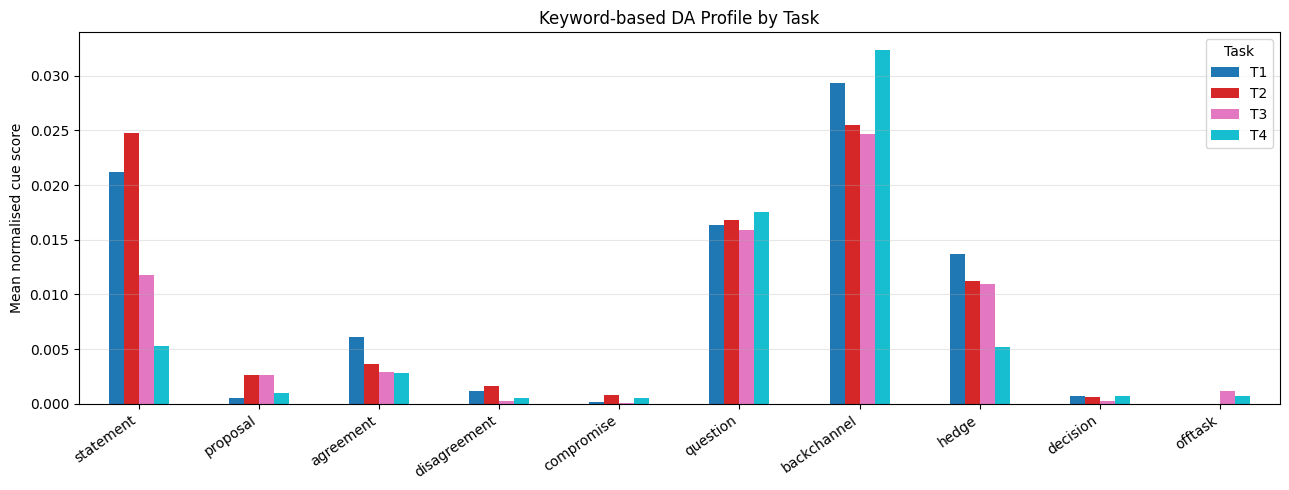

In [6]:
out_cols = [f'da_{k}' for k in DA_CATEGORIES]

# DA profile by task
task_profile = da_df.groupby('task_id')[out_cols].mean()
fig, ax = plt.subplots(figsize=(13, 5))
task_profile.T.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_xticklabels([c.replace('da_', '') for c in out_cols], rotation=35, ha='right')
ax.set_title('Keyword-based DA Profile by Task')
ax.set_ylabel('Mean normalised cue score')
ax.legend(title='Task')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

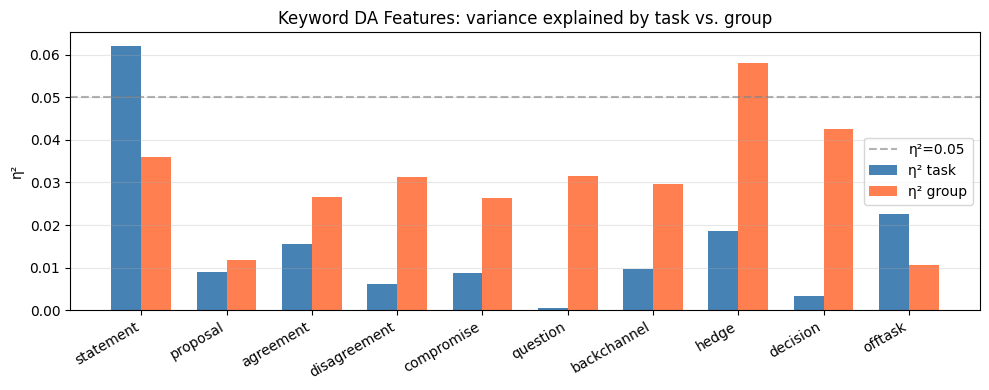

Mean η²_task  : 0.016
Mean η²_group : 0.030

BERT-UMAP for reference: η²_task=0.36, η²_group=0.06


In [7]:
# η² decomposition — compare with BERT-UMAP (η²_task=0.36, η²_group=0.06)
eta_rows = []
for col in out_cols:
    vals = da_df[col].values
    grand_mean = vals.mean()
    ss_total = ((vals - grand_mean) ** 2).sum()
    if ss_total == 0:
        continue
    task_masks = [(da_df['task_id'] == t).values for t in da_df['task_id'].unique()]
    ss_task = sum((vals[m].mean() - grand_mean) ** 2 * m.sum() for m in task_masks)
    grp_masks = [(da_df['group_id'] == g).values for g in da_df['group_id'].unique()]
    ss_grp = sum((vals[m].mean() - grand_mean) ** 2 * m.sum() for m in grp_masks)
    eta_rows.append({'Feature': col.replace('da_', ''),
                     'η²_task': ss_task / ss_total, 'η²_group': ss_grp / ss_total})

eta_df = pd.DataFrame(eta_rows)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(eta_df))
w = 0.35
ax.bar(x - w/2, eta_df['η²_task'],  w, label='η² task',  color='steelblue')
ax.bar(x + w/2, eta_df['η²_group'], w, label='η² group', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(eta_df['Feature'], rotation=30, ha='right')
ax.axhline(0.05, color='grey', linestyle='--', alpha=0.6, label='η²=0.05')
ax.set_title('Keyword DA Features: variance explained by task vs. group')
ax.set_ylabel('η²')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"Mean η²_task  : {eta_df['η²_task'].mean():.3f}")
print(f"Mean η²_group : {eta_df['η²_group'].mean():.3f}")
print()
print('BERT-UMAP for reference: η²_task=0.36, η²_group=0.06')

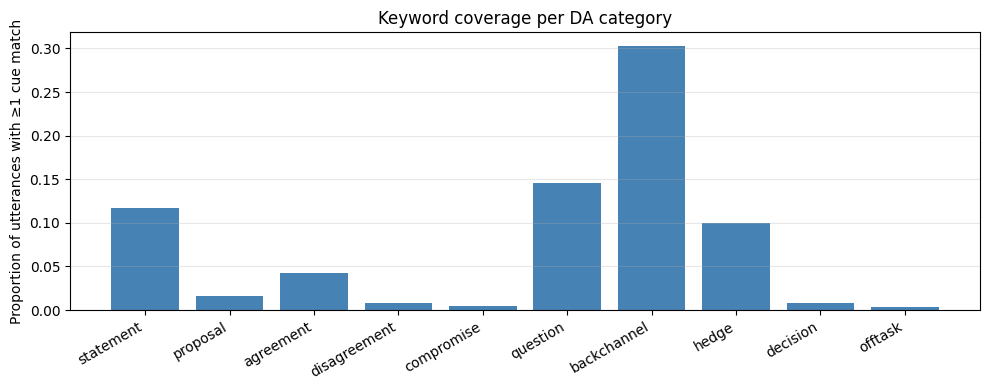

Coverage per category:
  backchannel    : 30.3%
  question       : 14.6%
  statement      : 11.7%
  hedge          : 10.0%
  agreement      : 4.2%
  proposal       : 1.6%
  decision       : 0.9%
  disagreement   : 0.8%
  compromise     : 0.4%
  offtask        : 0.3%


In [8]:
# Coverage: what % of utterances had at least one cue match per category?
coverage = {}
for da in DA_CATEGORIES:
    coverage[da] = (score_df[da] > 0).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(coverage.keys(), coverage.values(), color='steelblue')
ax.set_ylabel('Proportion of utterances with ≥1 cue match')
ax.set_title('Keyword coverage per DA category')
ax.set_xticklabels(coverage.keys(), rotation=30, ha='right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Coverage per category:')
for da, cov in sorted(coverage.items(), key=lambda x: -x[1]):
    print(f'  {da:15s}: {cov:.1%}')